## IMPORT STATEMENTS

In [4]:
import pprint
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 

In [5]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
plt.style.use("ggplot")
sns.set_palette("Set2")

## FETCHING THE DATASET

In [6]:
# fetch dataset 
heart_disease = fetch_ucirepo(id=45)
  
# data (as pandas dataframes) 
X = heart_disease.data.features
y = heart_disease.data.targets

In [7]:
print("DATASET SUMMARY:")
print(heart_disease.metadata.get('additional_info').get('summary'))

DATASET SUMMARY:
This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
   
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

To see Test Costs (donated by Peter Turney), please see the folder "Costs" 


## VARIABLES PRESENT IN THE DATASET

In [8]:
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [9]:
df = pd.concat([X, y], axis=1).rename(columns={'num':'target'})

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## DATA CLEANING

In [12]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert appropriate columns to numeric
df = df.apply(pd.to_numeric, errors="ignore")

## Number of Missing Values in the Dataset

In [13]:
missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing/len(df))*100
})

missing

,Missing Values,Percentage
age,0,0.000000
sex,0,0.000000
cp,0,0.000000
trestbps,0,0.000000
chol,0,0.000000
fbs,0,0.000000
restecg,0,0.000000
thalach,0,0.000000
exang,0,0.000000
oldpeak,0,0.000000


## FILL THE MISSING VALUES

In [14]:
# Fill missing values

for col in df.columns:
    if df[col].dtype == "object":
        # Fill categorical columns with mode
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        # Fill numerical columns with median
        df[col].fillna(df[col].median(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## CHECK FOR DUPLICATE ROWS

In [15]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [16]:
df = df.drop_duplicates()

print(df.shape)

(303, 14)


In [17]:
df["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

## EXPLORATORY DATA ANALYSIS

#### DISTRIBUTION OF HEART DISEASE

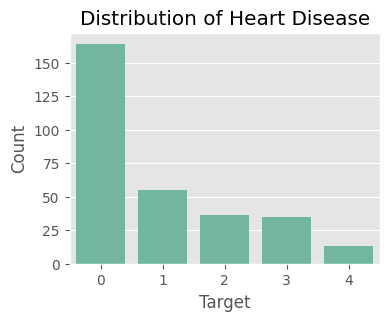

In [18]:
plt.figure(figsize=(4,3))

sns.countplot(data=df, x="target")

plt.title("Distribution of Heart Disease")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

INFERENCE: HEART DISEASE IS ABSENT IN MAJORITY OF THE PEOPLE

#### HISTOGRAMS TO CHECK DISTRIBUTION OF OTHER NUMERICAL FACTORS

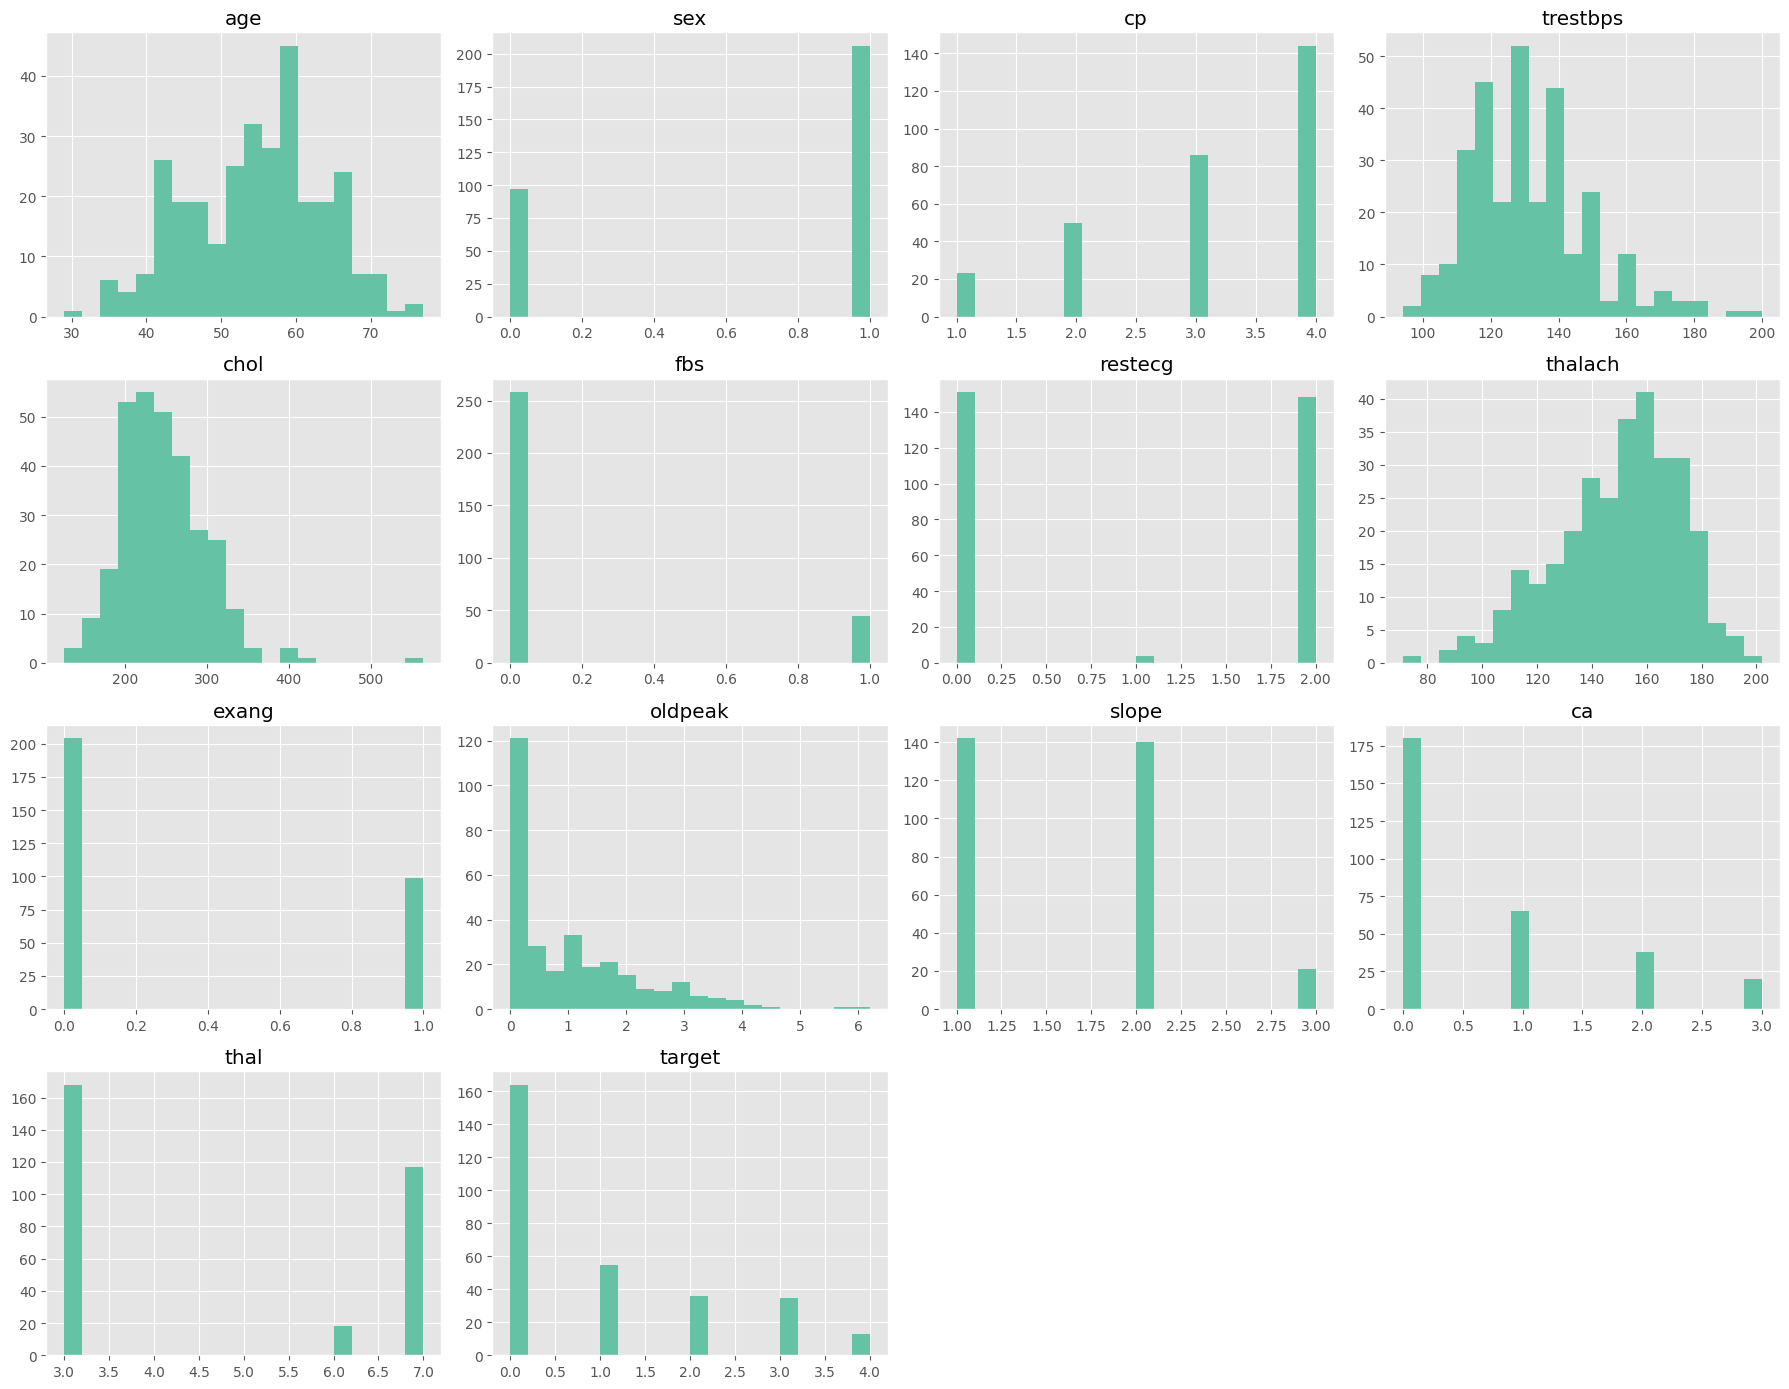

In [19]:
df.hist(figsize=(18,14), bins=20)

plt.tight_layout()

plt.show()

#### CORRELATION HEATMAP BETWEEN ALL VARIABLES

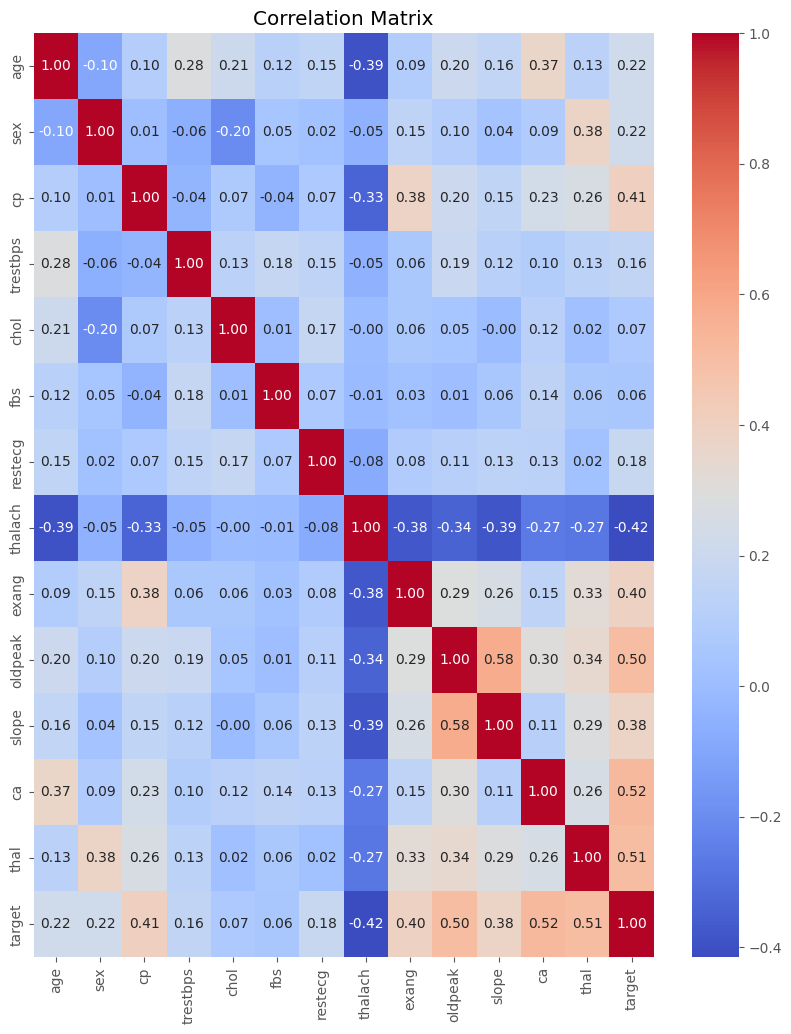

In [20]:
plt.figure(figsize=(10,12))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

INFERENCE: TARGET VARIABLE HAS HIGH CORRELATION WITH COLUMNS WITH OLDPEAK, CA, THAL, CP AND EXANG

#### BOXPLOT ON NUMERICAL COLUMNS TO CHECK FOR PRESENCE OF OUTLIERS

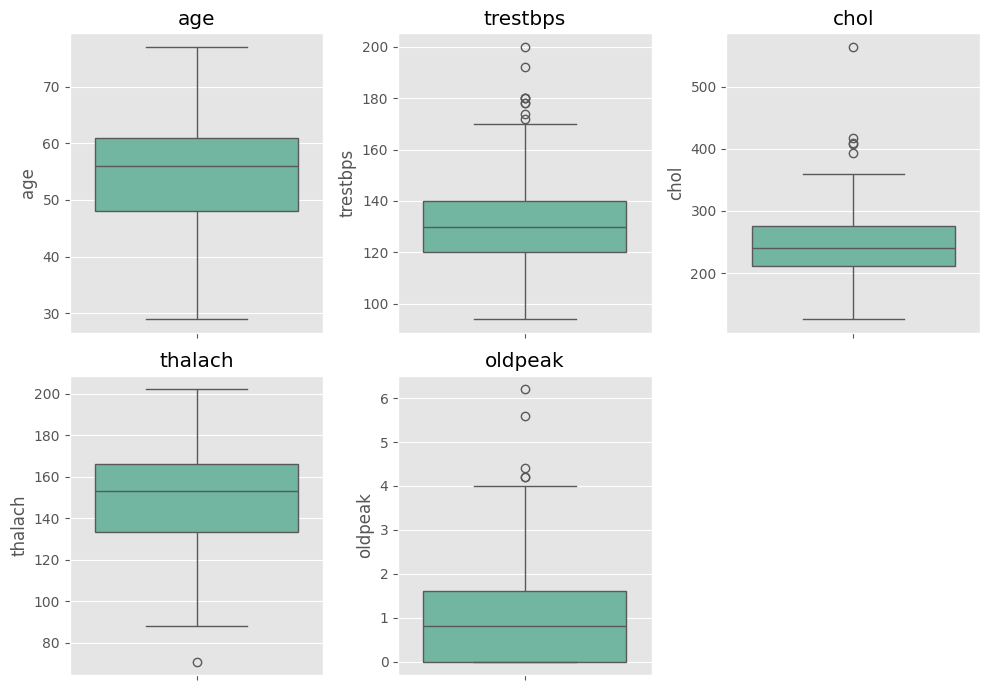

In [21]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

plt.figure(figsize=(10,7))

for i,col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

INFERENCE: OUTLIERS ARE DETECTED IN trestbp (resting BP), chol (cholestrol), and oldpeak

#### PAIRPLOT BETWEEN NUMERICAL VARIABLES TO SEE RELATION BETWEEN THEM

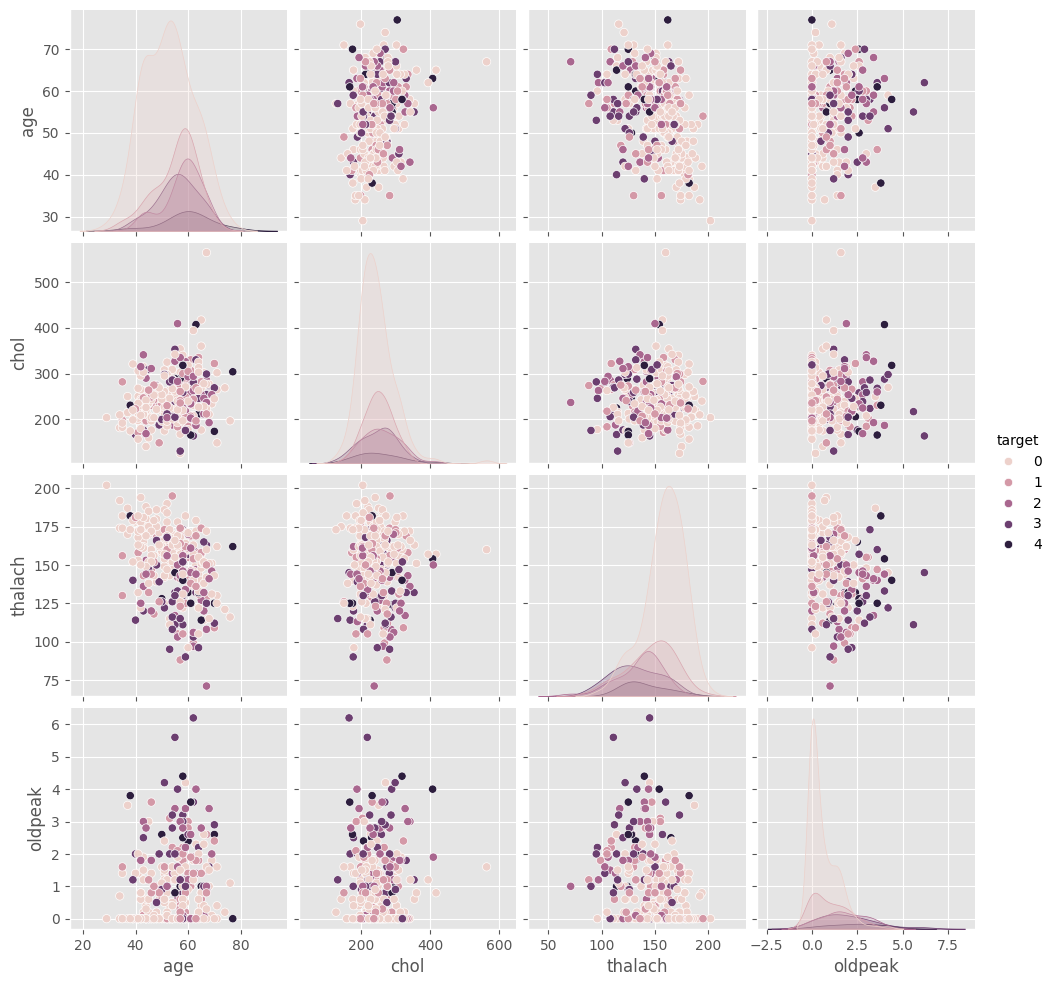

In [22]:
sns.pairplot(
    df[
        [
            "age",
            "chol",
            "thalach",
            "oldpeak",
            "target"
        ]
    ],
    hue="target"
)

plt.show()

#### DISTRIBUTION OF NUMERICAL COLUMNS IN THE DATASET

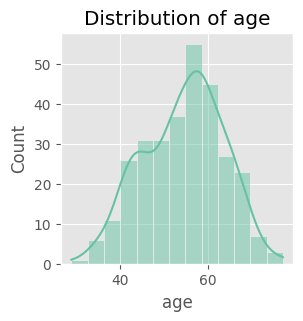

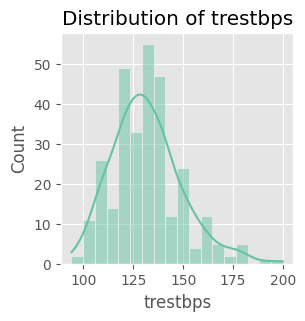

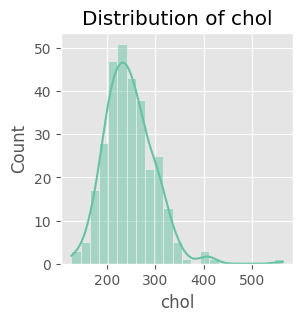

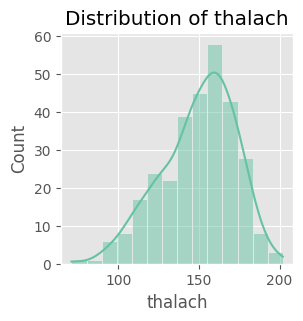

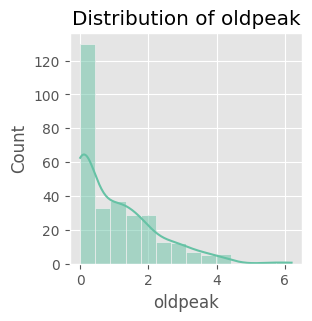

In [23]:
num_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for col in num_cols:

    plt.figure(figsize=(3,3))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

INFERENCE - SKEWED NORMAL DISTRIBUTION

#### DISTRIBUTION OF CATEGORICAL COLUMNS

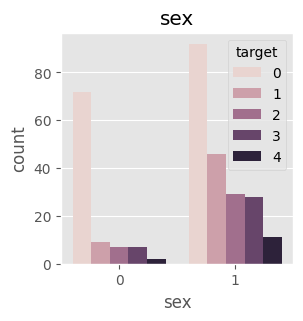

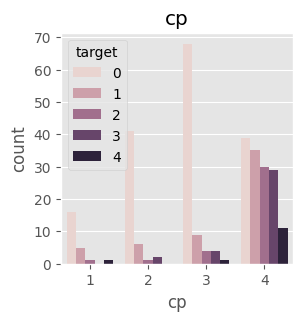

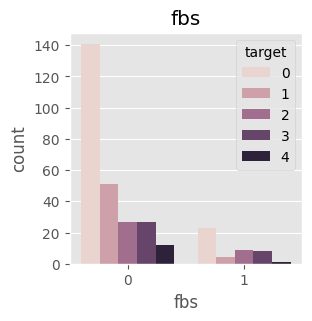

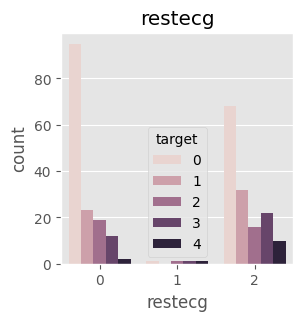

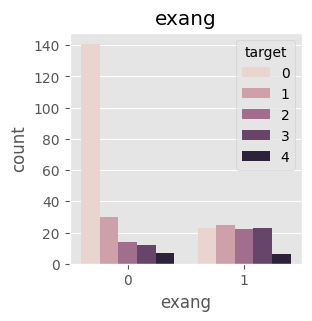

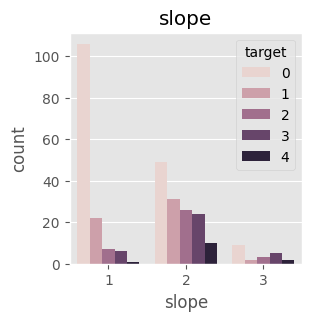

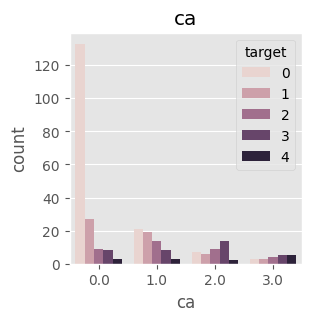

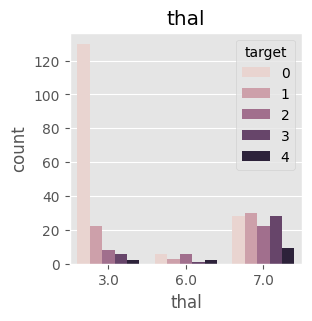

In [24]:
cat_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for col in cat_cols:

    plt.figure(figsize=(3,3))

    sns.countplot(data=df, x=col, hue="target")

    plt.title(col)

    plt.show()

#### BOX PLOT TO SEE DISTRIBUTION OF AGE FOR EACH TYPE OF HEART DISEASE

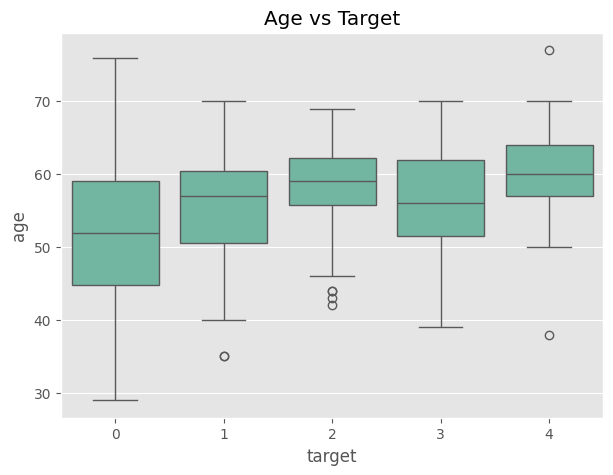

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="target",
    y="age"
)

plt.title("Age vs Target")

plt.show()

## SAVE THE UPDATED DATASET

In [29]:
df.to_csv("../data/processed/heart_clean.csv", index=False)
print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## CONCLUSION
1. The dataset contains no major missing value issues.
2. Duplicate records, if present, were removed.
3. The target variable is reasonably balanced.
4. Several numerical variables contain outliers but appear medically plausible.
5. Chest pain type, maximum heart rate, exercise-induced angina, and ST depression exhibit stronger relationships with heart disease.
6. The cleaned dataset has been saved for feature engineering and model development.